In [12]:
# Configuration cell (run this first)
PLOT_CFG = {
    # Global font settings
    "font_family": "DejaVu Sans",
    "font_color": "#111111",
    "title_fontsize": 20,
    "axis_label_fontsize": 16,
    "tick_label_fontsize": 14,
    "bar_value_fontsize": 14,
    "panel_label_fontsize": 20,

    # Figure sizes
    "figsize_trend": (14, 10),
    "figsize_wordcloud": (16, 10),

    # Trend bar settings
    "bar_width": 0.55,
    "article_bar_color": "#1f77b4",
    "selected_bar_color": "#d62728",
    "bar_alpha": 0.9,
    "force_integer_y_ticks": True,
    "y_axis_max_pad_ratio": 0.12,
    "y_axis_min_pad": 1,
    "bar_value_offset_ratio": 0.015,

    # Marker label box (a, b)
    "panel_box_facecolor": "#ffffff",
    "panel_box_edgecolor": "#000000",
    "panel_box_alpha": 0.95,

    # Word cloud settings
    "wc_article_colormap": "viridis",
    "wc_selected_colormap": "plasma",
    "wc_background_color": "white",
}

print("Configuration loaded. Edit PLOT_CFG values here anytime before running plot cells.")

Configuration loaded. Edit PLOT_CFG values here anytime before running plot cells.


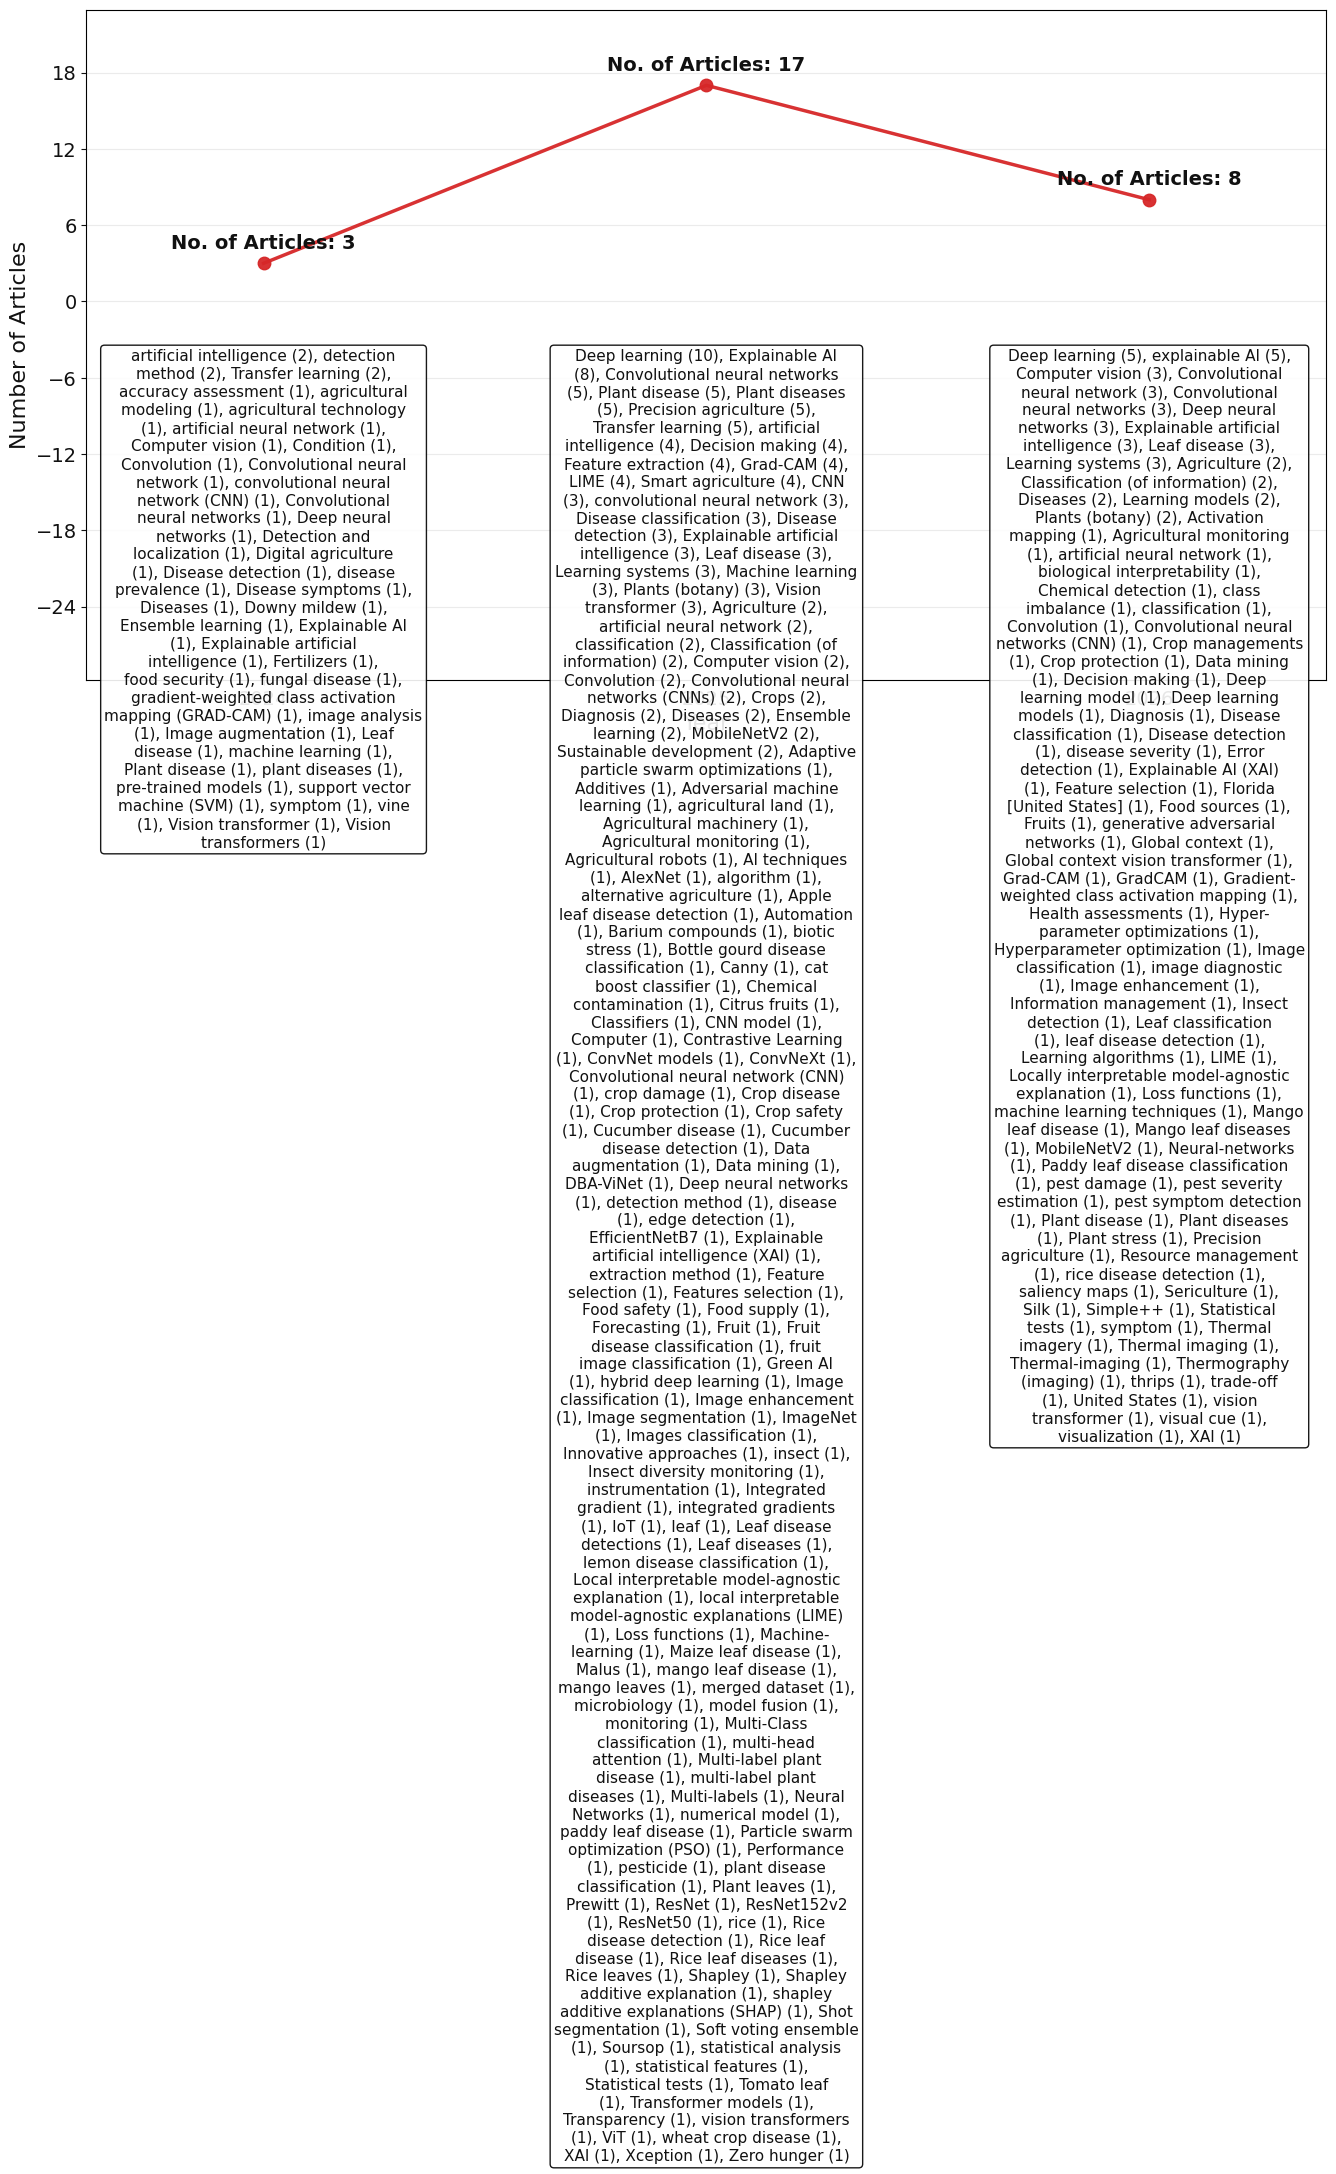

Saved timeline: C:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\codes\year_timeline_slr.png
Saved CSV: C:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\codes\year_keyword_summary_slr.csv
Using sheet: Final_selected
Using year column: Year
2024: 3 articles | keywords: artificial intelligence(2), detection method(2), Transfer learning(2), accuracy assessment(1), agricultural modeling(1), agricultural technology(1), artificial neural network(1), Computer vision(1), Condition(1), Convolution(1), Convolutional neural network(1), convolutional neural network (CNN)(1), Convolutional neural networks(1), Deep neural networks(1), Detection and localization(1), Digital agriculture(1), Disease detection(1), disease prevalence(1), Disease symptoms(1), Diseases(1), Downy mildew(1), Ensemble learning(1), Explainable AI(1), Explainable artificial intelligence(1), Fertilizers(1), food security(1), fungal disease(1), gradient-weighted class activation mapping (GRAD

In [19]:
from collections import Counter
from pathlib import Path
import re
import textwrap

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd

cfg = PLOT_CFG
plt.rcParams["font.family"] = cfg["font_family"]
plt.rcParams["text.color"] = cfg["font_color"]
plt.rcParams["axes.labelcolor"] = cfg["font_color"]
plt.rcParams["xtick.color"] = cfg["font_color"]
plt.rcParams["ytick.color"] = cfg["font_color"]

# --- File path ---
excel_path = Path(r"c:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\RAW\Main_database1.xlsx")

# --- Helpers ---
def find_sheet_name(sheet_names, preferred):
    low_map = {s.lower().strip(): s for s in sheet_names}

    for name in preferred:
        if name.lower().strip() in low_map:
            return low_map[name.lower().strip()]

    for s in sheet_names:
        s_low = s.lower().strip()
        if any(name.lower().strip() in s_low for name in preferred):
            return s

    raise ValueError(f"Could not find sheet. Available sheets: {sheet_names}")


def detect_year_column(df):
    candidates = []
    for c in df.columns:
        c_low = str(c).lower()
        if "year" in c_low or "publication" in c_low or "pub" in c_low:
            candidates.append(c)

    if not candidates:
        raise ValueError(f"No year-like column found in columns: {list(df.columns)}")

    best_col = candidates[0]
    best_score = -1
    for c in candidates:
        s = pd.to_numeric(df[c], errors="coerce")
        score = s.notna().sum()
        if score > best_score:
            best_score = score
            best_col = c
    return best_col


def clean_year_series(series):
    s = series.astype(str).str.extract(r"(19\d{2}|20\d{2}|21\d{2})", expand=False)
    s = pd.to_numeric(s, errors="coerce").dropna().astype(int)
    s = s[(s >= 1900) & (s <= 2100)]
    return s


def split_keywords(value):
    if pd.isna(value):
        return []
    parts = re.split(r"[;,|\n\t]+", str(value))
    keywords = []
    for part in parts:
        cleaned = re.sub(r"\s+", " ", part).strip()
        cleaned = cleaned.strip(" .")
        if cleaned and cleaned.lower() != "nan":
            keywords.append(cleaned)
    return keywords


def normalize_keyword(value):
    normalized = re.sub(r"\s+", " ", str(value)).strip().lower()
    if not normalized or not re.search(r"[a-zA-Z]", normalized):
        return ""
    return normalized


def count_keywords_by_year(df, year_column):
    article_counts = Counter()
    year_keyword_counts = {}
    year_display_names = {}

    keyword_columns = [c for c in ["Author Keywords", "Index Keywords"] if c in df.columns]
    if not keyword_columns:
        raise ValueError("No keyword columns found in the final selected sheet.")

    for _, row in df.iterrows():
        year_raw = row.get(year_column, pd.NA)
        year_clean = clean_year_series(pd.Series([year_raw]))
        if year_clean.empty:
            continue
        year = int(year_clean.iloc[0])
        article_counts[year] += 1
        year_keyword_counts.setdefault(year, Counter())
        year_display_names.setdefault(year, {})

        row_keywords = set()
        for col in keyword_columns:
            for keyword in split_keywords(row.get(col, pd.NA)):
                normalized = normalize_keyword(keyword)
                if normalized:
                    row_keywords.add(normalized)
                    year_display_names[year].setdefault(normalized, keyword)

        for keyword in row_keywords:
            year_keyword_counts[year][keyword] += 1

    return article_counts, year_keyword_counts, year_display_names


def build_year_keyword_table(article_counts, year_keyword_counts, year_display_names):
    rows = []
    for year in sorted(article_counts):
        items = sorted(
            year_keyword_counts.get(year, Counter()).items(),
            key=lambda item: (-item[1], year_display_names.get(year, {}).get(item[0], item[0]).lower()),
        )
        for keyword, count in items:
            rows.append({
                "Year": year,
                "Keyword": year_display_names.get(year, {}).get(keyword, keyword),
                "Count": count,
                "Display": f"{year_display_names.get(year, {}).get(keyword, keyword)} ({count})",
                "Article_Count": article_counts[year],
            })
    return pd.DataFrame(rows)


# --- Read workbook and final SLR sheet ---
xls = pd.ExcelFile(excel_path)
slr_sheet = find_sheet_name(xls.sheet_names, ["final_selected", "final selected", "final"] )
slr_df = pd.read_excel(excel_path, sheet_name=slr_sheet)

# --- Detect year column and keyword frequencies by year ---
slr_year_col = detect_year_column(slr_df)
article_counts, year_keyword_counts, year_display_names = count_keywords_by_year(slr_df, slr_year_col)
years = sorted(article_counts.keys())

if not years:
    raise ValueError(f"No valid year values found in column: {slr_year_col}")

year_keyword_table = build_year_keyword_table(article_counts, year_keyword_counts, year_display_names)
csv_out = Path("year_keyword_summary_slr.csv")
year_keyword_table.to_csv(csv_out, index=False, encoding="utf-8-sig")

# --- Plot: timeline with year counts and all unique keywords ---
fig, ax = plt.subplots(figsize=(16, 10))
line_color = cfg["selected_bar_color"]

ax.plot(
    years,
    [article_counts[year] for year in years],
    color=line_color,
    marker="o",
    linewidth=2.5,
    markersize=9,
    zorder=3,
    alpha=0.95,
    label="Articles per year",
)

ax.set_xlabel("Year", fontsize=cfg["axis_label_fontsize"])
ax.set_ylabel("Number of Articles", fontsize=cfg["axis_label_fontsize"])
ax.set_xticks(years)
ax.set_xlim(min(years) - 0.4, max(years) + 0.4)
ax.tick_params(axis="both", labelsize=cfg["tick_label_fontsize"])
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

max_count = max(article_counts.values())
ax.set_ylim(-max_count * 1.75, max_count * 1.35)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

for year in years:
    count = article_counts[year]
    ax.text(
        year,
        count + max(0.35, max_count * 0.05),
        f"No. of Articles: {count}",
        ha="center",
        va="bottom",
        fontsize=cfg["bar_value_fontsize"],
        fontweight="bold",
    )

    keyword_items = sorted(
        year_keyword_counts.get(year, Counter()).items(),
        key=lambda item: (-item[1], year_display_names.get(year, {}).get(item[0], item[0]).lower()),
    )
    if keyword_items:
        keyword_lines = [f"{year_display_names.get(year, {}).get(keyword, keyword)} ({count})" for keyword, count in keyword_items]
        keyword_text = "\n".join(textwrap.wrap(", ".join(keyword_lines), width=38))
    else:
        keyword_text = "No keywords found"

    ax.text(
        year,
        -max_count * 0.22,
        keyword_text,
        ha="center",
        va="top",
        fontsize=11,
        linespacing=1.25,
        wrap=True,
        clip_on=False,
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": cfg["panel_box_facecolor"],
            "edgecolor": cfg["panel_box_edgecolor"],
            "alpha": 0.9,
        },
    )

plt.subplots_adjust(bottom=0.28, top=0.95)
out1 = Path("year_timeline_slr.png")
plt.savefig(out1, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved timeline: {out1.resolve()}")
print(f"Saved CSV: {csv_out.resolve()}")
print(f"Using sheet: {slr_sheet}")
print(f"Using year column: {slr_year_col}")
for year in years:
    items = sorted(year_keyword_counts.get(year, Counter()).items(), key=lambda item: (-item[1], year_display_names.get(year, {}).get(item[0], item[0]).lower()))
    print(f"{year}: {article_counts[year]} articles | keywords: {', '.join(f'{year_display_names.get(year, {}).get(keyword, keyword)}({count})' for keyword, count in items) if items else 'None'}")

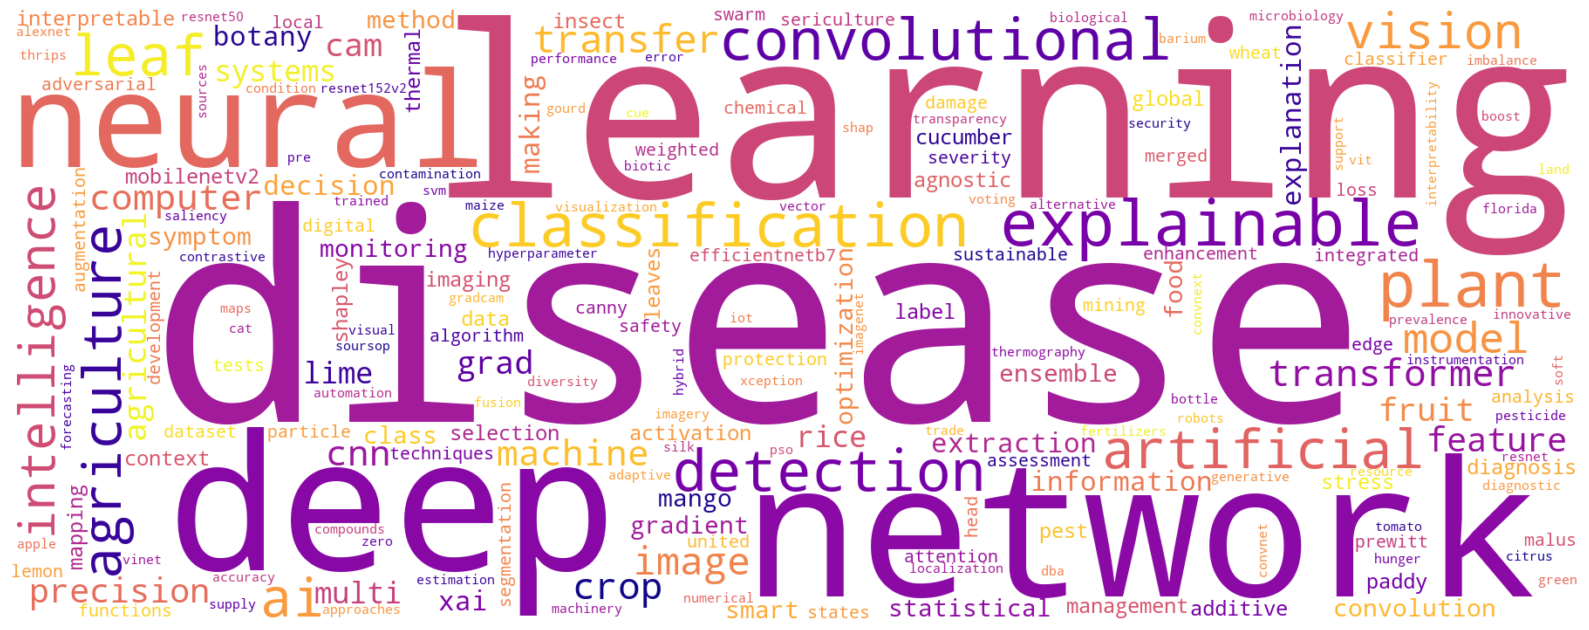

Saved: C:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\codes\keyword_wordcloud_slr.png
Using sheet: Final_selected
Using keyword columns: ['Author Keywords', 'Index Keywords']


In [16]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import STOPWORDS, WordCloud

cfg = PLOT_CFG
plt.rcParams["font.family"] = cfg["font_family"]
plt.rcParams["text.color"] = cfg["font_color"]
plt.rcParams["axes.labelcolor"] = cfg["font_color"]
plt.rcParams["xtick.color"] = cfg["font_color"]
plt.rcParams["ytick.color"] = cfg["font_color"]

# --- File path ---
excel_path = Path(r"c:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\RAW\Main_database1.xlsx")

# Choose keyword source: "author", "index", or "both"
KEYWORD_MODE = "both"

# --- Helpers ---
def find_sheet_name(sheet_names, preferred):
    low_map = {s.lower().strip(): s for s in sheet_names}

    for name in preferred:
        if name.lower().strip() in low_map:
            return low_map[name.lower().strip()]

    for s in sheet_names:
        s_low = s.lower().strip()
        if any(name.lower().strip() in s_low for name in preferred):
            return s

    raise ValueError(f"Could not find sheet. Available sheets: {sheet_names}")


def detect_keyword_columns(df):
    cols = []
    for c in df.columns:
        c_low = str(c).lower()
        if "keyword" in c_low:
            cols.append(c)

    if cols:
        return cols

    fallback_names = ["author keywords", "index keywords", "keywords plus"]
    for c in df.columns:
        c_low = str(c).lower().strip()
        if c_low in fallback_names:
            cols.append(c)

    if not cols:
        raise ValueError(f"No keyword-like columns found in columns: {list(df.columns)}")

    return cols


def choose_keyword_columns(df, mode):
    all_cols = detect_keyword_columns(df)
    author_cols = [c for c in all_cols if "author" in str(c).lower()]
    index_cols = [c for c in all_cols if "index" in str(c).lower()]

    mode = mode.lower().strip()
    if mode == "author":
        chosen = author_cols
    elif mode == "index":
        chosen = index_cols
    elif mode == "both":
        chosen = list(dict.fromkeys(author_cols + index_cols))
        if not chosen:
            chosen = all_cols
    else:
        raise ValueError("KEYWORD_MODE must be 'author', 'index', or 'both'.")

    if not chosen:
        raise ValueError(f"No columns found for KEYWORD_MODE='{mode}'. Available keyword columns: {all_cols}")

    return chosen


def extract_keyword_text(df, keyword_cols):
    text_parts = []
    for col in keyword_cols:
        series = df[col].dropna().astype(str)
        text_parts.extend(series.tolist())
    return " ; ".join(text_parts)


def normalize_for_wordcloud(text):
    tokens = re.split(r"[;,|\n\t]+", text)
    cleaned = []
    for t in tokens:
        t = re.sub(r"[^a-zA-Z0-9\-\s]", " ", t).strip().lower()
        t = re.sub(r"\s+", " ", t)
        if len(t) >= 3 and t not in STOPWORDS:
            cleaned.append(t)
    return " ".join(cleaned)


# --- Read workbook and final SLR sheet ---
xls = pd.ExcelFile(excel_path)
slr_sheet = find_sheet_name(xls.sheet_names, ["final_selected", "final selected", "final"] )
slr_df = pd.read_excel(excel_path, sheet_name=slr_sheet)

# --- Detect and choose keyword columns ---
slr_keyword_cols = choose_keyword_columns(slr_df, KEYWORD_MODE)
slr_text = normalize_for_wordcloud(extract_keyword_text(slr_df, slr_keyword_cols))

wc_slr = WordCloud(
    width=1800,
    height=700,
    background_color=cfg["wc_background_color"],
    colormap=cfg["wc_selected_colormap"],
    stopwords=set(STOPWORDS),
    collocations=False,
).generate(slr_text if slr_text.strip() else "no keywords")

# --- Plot (Image 2): SLR keyword word cloud ---
fig, ax = plt.subplots(figsize=cfg["figsize_wordcloud"] )
ax.imshow(wc_slr, interpolation="bilinear")
ax.axis("off")

plt.tight_layout()
out2 = Path("keyword_wordcloud_slr.png")
plt.savefig(out2, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out2.resolve()}")
print(f"Using sheet: {slr_sheet}")
print(f"Using keyword columns: {slr_keyword_cols}")